# ADA boost model benchmark

In [39]:
# installation 
%pip install scikit-learn numpy matplotlib pandas seaborn xgboost tqdm

Note: you may need to restart the kernel to use updated packages.


In [40]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [41]:
VERBOSE = 0
N_ESTIMATORS = 100
LEARNING_RATE = 1

# Model definition

In [42]:
# simple AdaBoostClassifier
# abc = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth= ), n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE)

# MinMaxScaler for dataset normalization
scaler = MinMaxScaler()

# Load and preprocess data

In [43]:
# load all datasets
df_chall = pd.read_csv('../datasets/challenger_dataset.csv')
# df_grandMaster = pd.read_csv('../datasets/grandmaster_dataset.csv')
# df_master = pd.read_csv('../datasets/master_dataset.csv')

In [44]:
# concatenate and drop all value that represent the start of the game / are invalide
# df = pd.concat([df_chall, df_grandMaster, df_master])
df = df_chall

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]
df.fillna(df.median(), inplace=True)
a = df['timestamp']
df.drop(columns=['timestamp'], inplace=True)

In [45]:
# normalization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

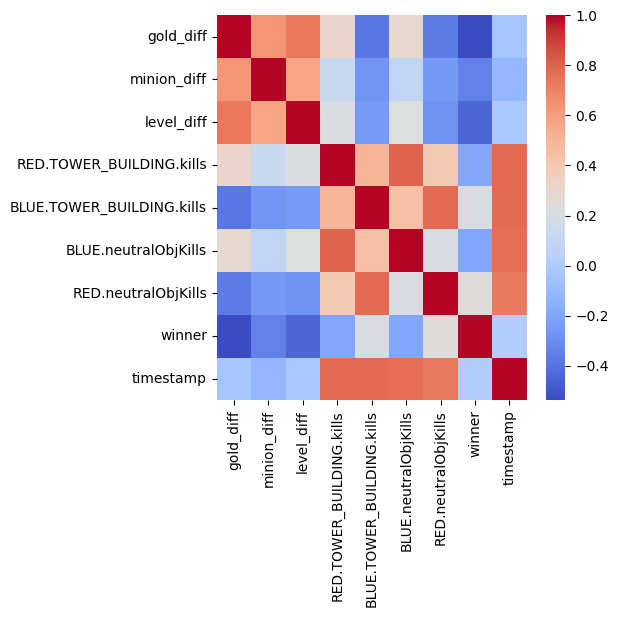

In [46]:
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']
tdf["timestamp"] = a

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [47]:
# final split 
X = tdf.drop('winner', axis=1)[:100000]
y = tdf['winner'][:100000]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80000, 8) (20000, 8) (80000,) (20000,)


# Train the model

In [48]:
import itertools
from tqdm import tqdm
import time


def grid_search(param_grid, build_model, fit, predict, condition, best_score_start, X_train, y_train, X_test, y_test):
    best_score = best_score_start
    best_params = {}

    param_combinations = itertools.product(*param_grid.values())
    len_data =np.prod([len(v) for v in param_grid.values()])
    print(f"Starting grid search over {len_data} parameter combinations...\n")


    start_time = time.time()

    for i, combination in enumerate(tqdm(param_combinations, desc="Grid Search Progress", total=len_data)):
        params = dict(zip(param_grid.keys(), combination))
        try: 
            model = build_model(params)
    
            fit(model, X_train, y_train)
    
            score = predict(model, X_test, y_test)
        except Exception as e:
            print(f'Warning: model, fit or score is crashing {e}')
            continue

        if condition(score, best_score):
            best_score = score
            best_params = params

    end_time = time.time()
    time_taken = end_time - start_time
    print(f"\nGrid Search Completed in {time_taken:.2f} seconds.")

    print(f"\nBest Parameters: {best_params}")
    print(f"Best Score: {best_score:.4f}")
    return best_params

In [ ]:
param_grid = {
    "n_estimators": [200, 250, 300],
    "learning_rate": [1.0, 1.2, 1.4],
    "estimator__max_depth": [1, 2, 3, 4]
}

grid_search = grid_search(param_grid, lambda params: AdaBoostClassifier(
                                random_state=42,
                                estimator=DecisionTreeClassifier(max_depth=params["estimator__max_depth"], random_state=42), 
                                n_estimators=params["n_estimators"], 
                                learning_rate=params["learning_rate"]),
                            lambda model, X, y: model.fit(X, y),
                            lambda model, X, y: model.score(X, y),
                            lambda score, best_score: score > best_score,
                            -np.inf,
                            X_train, y_train, X_test, y_test)
print(grid_search)

In [ ]:
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=grid_search["estimator__max_depth"]), 
                            n_estimators=grid_search["n_estimators"], 
                            learning_rate=grid_search["learning_rate"])
model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                   learning_rate=1.2, n_estimators=250)

# Evaluation metrics

In [51]:
from sklearn.metrics import accuracy_score

print(f"Accuracy of AdaBoostClassifier: {model.score(X_test, y_test)}")
# print(f"Accuracy of AdaBoostClassifier with RandomForest: {model_rf.score(X_test, y_test)}")

Accuracy of AdaBoostClassifier: 0.73805


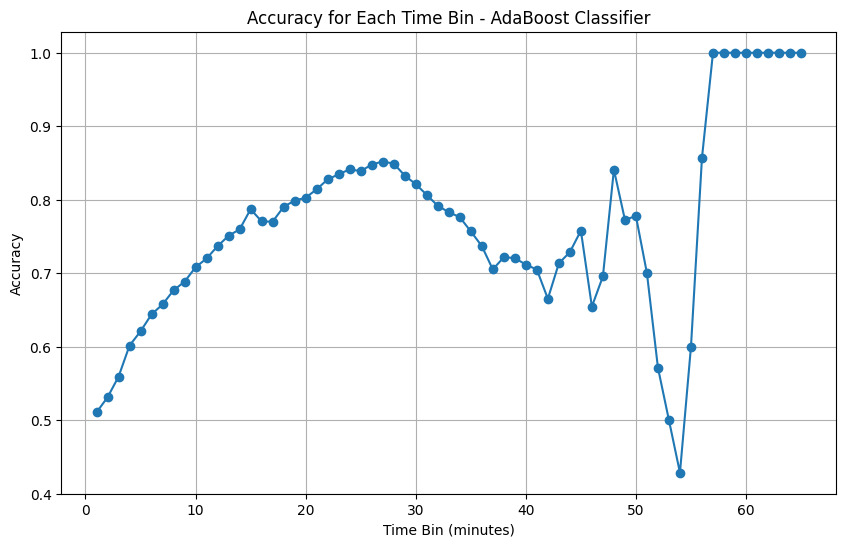

In [53]:
tdf["time_bin"] = (tdf["timestamp"] // 60000) * 60000

def predict_classifier(model, X_test, y_test):
    pred = model.predict(X_test)
    return accuracy_score(y_test, pred)

def predict_regressor(model, X_test, y_test):
    pred = model.predict(X_test)
    return accuracy_score(y_test, np.round(np.clip(pred, 0, 1)))

def plot_accuracy_over_time(model, label, df, prediction):
    minutes = []
    accuracies = []
    for time_bin, df_bin in df.groupby("time_bin"):
        minutes.append(time_bin // 60000)
        X_test_bin = df_bin.drop(columns=["winner", "time_bin"])
        y_test_bin = df_bin["winner"]
        accuracies.append(prediction(model, X_test_bin, y_test_bin))

    plt.figure(figsize=(10, 6))
    plt.plot(minutes, accuracies, marker='o', linestyle='-')
    plt.title(f'Accuracy for Each Time Bin - {label}')
    plt.xlabel('Time Bin (minutes)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

plot_accuracy_over_time(model, 'AdaBoost Classifier', tdf, predict_classifier)